# **Project 2: Model Compression on CIFAR 10 dataset**

# Setup

First, install the required packages and download the datasets and pretrained model.

In [1]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
All required packages have been successfully installed!


In [2]:
import copy
import math
import random
import time
from collections import OrderedDict, defaultdict
from typing import Union, List

import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import nn
import torchvision
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *
from tqdm.auto import tqdm


import torch.nn.functional as F

assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


In [4]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# **Load the MNIST dataset.**

In [5]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
to_image = lambda t: (t*0.3081+0.1307).squeeze(0).to('cpu').numpy()

dataset = {}
for split in ["train", "test"]:
  dataset[split] = MNIST(
    "data",
    train=(split == "train"),
    download=(split == "train"),
    transform=transform,
  )

dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=256 if split == 'train' else 1000,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True
  )

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


In [6]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    ])
#to_image = lambda t: (t*0.3081+0.1307).squeeze(0).to('cpu').numpy()

dataset_CIFAR = {}
for split in ["train", "test"]:
  dataset_CIFAR[split] = CIFAR10(
    "data",
    train=(split == "train"),
    download=(split == "train"),
    transform=transform,
  )

dataloader_CIFAR = {}
for split in ['train', 'test']:
  dataloader_CIFAR[split] = DataLoader(
    dataset_CIFAR[split],
    batch_size=256 if split == 'train' else 1000,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True
  )

  cnn_train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform)

  cnn_train_loader = DataLoader(
    cnn_train_set,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
  cnn_test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform)

  cnn_test_loader = DataLoader(
    cnn_test_set,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


Create a set of test images for demo.

In [8]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    #plt.title(cnn_train_set.classes[label])
    plt.title(dataset_CIFAR['train'].classes[label])
    plt.axis("off")
    plt.show()

In [9]:
#batch = next(iter(dataloader['train']))
x, y = dataset_CIFAR['train'][3]  # assuming dataset returns (input, label)



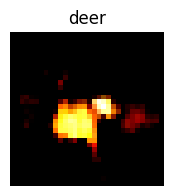

In [10]:
show_image(x,y)

In [11]:
dataset_CIFAR['train'].classes[y]

'deer'

In [12]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)

        plt.title(dataset_CIFAR['train'].classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

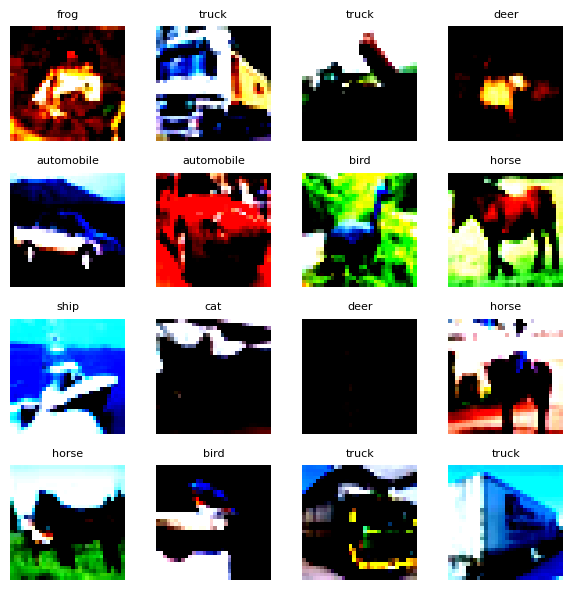

In [13]:
show_batch(dataset_CIFAR['train'], n=16)

# Helper Functions (Flops, Model Size calculation, etc.)

In [7]:
def calculate_layer_macs(layer, input_shape, count_nonzero_only=False):
    total_macs = 0
    if isinstance(layer, Conv2D):
        N, C_in, H_in, W_in = input_shape
        C_out = layer.out_channels
        K_H = layer.kernel_size
        K_W = layer.kernel_size
        S = layer.stride
        P = layer.padding

        H_out = (H_in + 2 * P - K_H) // S + 1
        W_out = (W_in + 2 * P - K_W) // S + 1

        dense_macs_for_layer = N * C_out * H_out * W_out * C_in * K_H * K_W
        if count_nonzero_only:
            num_nonzero_weights = layer.W.count_nonzero().item()
            if layer.W.numel() > 0:
                sparse_factor = num_nonzero_weights / layer.W.numel()
                total_macs = dense_macs_for_layer * sparse_factor
            else:
                total_macs = 0 # No weights, no macs
        else:
            total_macs = dense_macs_for_layer
        return total_macs, (N, C_out, H_out, W_out)

    elif isinstance(layer, Linear):
        N, I = input_shape
        O = layer.b.numel() # out_features

        dense_macs_for_layer = N * I * O
        if count_nonzero_only:
            num_nonzero_weights = layer.W.count_nonzero().item()
            if layer.W.numel() > 0:
                sparse_factor = num_nonzero_weights / layer.W.numel()
                total_macs = dense_macs_for_layer * sparse_factor
            else:
                total_macs = 0 # No weights, no macs
        else:
            total_macs = dense_macs_for_layer
        return total_macs, (N, O)

    elif isinstance(layer, (MaxPool2D, ReLU)):
        if isinstance(layer, MaxPool2D):
            # MaxPool2D always operates on 4D input (N, C, H, W)
            N, C, H_in, W_in = input_shape
            K = layer.kernel_size
            S = layer.stride
            H_out = (H_in - K) // S + 1
            W_out = (W_in - K) // S + 1
            return 0, (N, C, H_out, W_out)
        else: # ReLU
            # ReLU can operate on 2D (after Linear) or 4D (after Conv/Pool)
            return 0, input_shape
    else:
        return 0, input_shape

def get_manual_model_macs(model, inputs, count_nonzero_only=False) -> int:
    total_macs = 0
    current_shape = inputs.shape # (N, C, H, W)

    # Block 1
    macs, current_shape = calculate_layer_macs(model.conv1, current_shape, count_nonzero_only)
    total_macs += macs
    _, current_shape = calculate_layer_macs(model.relu1, current_shape)
    macs, current_shape = calculate_layer_macs(model.pool1, current_shape)
    total_macs += macs # Pool has 0 MACs, but calling it for consistent shape tracking

    # Block 2
    macs, current_shape = calculate_layer_macs(model.conv2, current_shape, count_nonzero_only)
    total_macs += macs
    _, current_shape = calculate_layer_macs(model.relu2, current_shape)
    macs, current_shape = calculate_layer_macs(model.pool2, current_shape)
    total_macs += macs

    # Block 3
    macs, current_shape = calculate_layer_macs(model.conv3, current_shape, count_nonzero_only)
    total_macs += macs
    _, current_shape = calculate_layer_macs(model.relu3, current_shape)
    macs, current_shape = calculate_layer_macs(model.pool3, current_shape)
    total_macs += macs

    # Flatten
    N, C, H, W = current_shape
    flattened_size = C * H * W
    current_shape = (N, flattened_size)

    # FC
    macs, current_shape = calculate_layer_macs(model.fc1, current_shape, count_nonzero_only)
    total_macs += macs
    _, current_shape = calculate_layer_macs(model.relu4, current_shape)
    macs, current_shape = calculate_layer_macs(model.fc2, current_shape, count_nonzero_only)
    total_macs += macs

    return total_macs

def get_model_macs(model, inputs, count_nonzero_only=False) -> int:
    if isinstance(model, torch.nn.Module): # For standard PyTorch nn.Module models
        # profile_macs might still fail if the nn.Module contains custom operations
        return profile_macs(model, inputs)
    elif isinstance(model, ManualCNN_opt_maxpool): # For your custom model
        return get_manual_model_macs(model, inputs, count_nonzero_only)
    else:
        raise TypeError(f"Unsupported model type: {type(model)}. Cannot calculate MACs.")

def get_sparsity(tensor: torch.Tensor) -> float:
    """
    calculate the sparsity of the given tensor
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    return 1 - float(tensor.count_nonzero()) / tensor.numel()


def get_model_sparsity(model: nn.Module) -> float:
    """
    calculate the sparsity of the given model
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements

def get_num_parameters(model, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    if hasattr(model, 'parameters'): # For torch.nn.Module models
        for param in model.parameters():
            if count_nonzero_only:
                num_counted_elements += param.count_nonzero()
            else:
                num_counted_elements += param.numel()
    elif hasattr(model, 'params'): # For custom models like ManualCNN_opt_maxpool
        for param, _ in model.params(): # model.params() returns (param, grad) tuples
            if count_nonzero_only:
                num_counted_elements += param.count_nonzero()
            else:
                num_counted_elements += param.numel()
    else:
        raise AttributeError("Model does not have 'parameters()' or 'params()' method.")
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

In [ ]:
def train(
  model: nn.Module,
  dataloader: DataLoader,
  criterion: nn.Module,
  optimizer: Optimizer,
  scheduler: StepLR,
  callbacks = None
) -> None:
  model.train()

  for inputs, targets in tqdm(dataloader, desc='train', leave=False):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    # Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update optimizer
    optimizer.step()

    if callbacks is not None:
        for callback in callbacks:
            callback()

  # Update scheduler
  scheduler.step()

In [ ]:
@torch.inference_mode()
def evaluate(
  model: nn.Module,
  dataloader: DataLoader,
  verbose=True,
) -> float:
  model.eval()

  num_samples = 0
  num_correct = 0

  for inputs, targets in tqdm(dataloader, desc="eval", leave=False,
                              disable=not verbose):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

Define pruning functions.

In [14]:
def fine_grained_prune(tensor: torch.Tensor, sparsity : float) -> torch.Tensor:
    """
    magnitude-based pruning for single tensor
    :param tensor: torch.(cuda.)Tensor, weight of conv/fc layer
    :param sparsity: float, pruning sparsity
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    :return:
        torch.(cuda.)Tensor, mask for zeros
    """
    sparsity = min(max(0.0, sparsity), 1.0)
    if sparsity == 1.0:
        tensor.zero_()
        return torch.zeros_like(tensor)
    elif sparsity == 0.0:
        return torch.ones_like(tensor)

    num_elements = tensor.numel()

    num_zeros = round(num_elements * sparsity)
    importance = tensor.abs()
    threshold = importance.view(-1).kthvalue(num_zeros).values
    mask = torch.gt(importance, threshold)
    tensor.mul_(mask)

    return mask

In [15]:
class FineGrainedPruner:
    def __init__(self, model, sparsity_dict):
        # Determine how to access parameters based on model type
        self._param_info = [] # Stores (name, param_tensor) for pruning and applying
        if hasattr(model, 'named_parameters'):
            for name, param in model.named_parameters():
                if param.dim() > 1: # Only consider prunable layers (conv/fc weights)
                    self._param_info.append((name, param))
        elif hasattr(model, 'params'): # Custom models
            for i, (param, _) in enumerate(model.params()):
                if param.dim() > 1: # Only consider prunable layers
                    # For custom models without explicit names, use an index-based name
                    self._param_info.append((f"custom_param_{i}", param))
        else:
            raise AttributeError("Model does not have 'named_parameters()' or 'params()' method.")

        self.masks = self._prune_internal(sparsity_dict)

    @torch.no_grad()
    def apply(self, model):
        # Re-iterate through param_info to apply masks
        # This assumes the order of params hasn't changed, which it shouldn't for a given model instance
        for name, param in self._param_info:
            if name in self.masks:
                param.data.mul_(self.masks[name]) # Use .data to modify in-place without tracking gradients

    @torch.no_grad()
    def _prune_internal(self, sparsity_dict):
        masks = dict()
        for name, param in self._param_info:
            current_sparsity = 0.0
            if isinstance(sparsity_dict, dict):
                current_sparsity = sparsity_dict.get(name, 0.0) # Get specific sparsity or default to 0
            else: # Global sparsity
                current_sparsity = sparsity_dict

            if current_sparsity > 0:
                masks[name] = fine_grained_prune(param, current_sparsity)
            else:
                masks[name] = torch.ones_like(param) # No pruning, so mask is all ones
        return masks

# Actual Model Code

In [16]:
import torch
import torch.nn.functional as F
import math


# ==================================================
# Manual zero padding
# ==================================================
def manual_pad(x, pad):
    if pad == 0:
        return x

    N, C, H, W = x.shape
    out = torch.zeros(
        (N, C, H + 2 * pad, W + 2 * pad),
        device=x.device,
        dtype=x.dtype
    )
    out[:, :, pad:pad + H, pad:pad + W] = x
    return out


# ==================================================
# Manual ReLU
# ==================================================
class ReLU:
    def forward(self, x):
        self.mask = (x > 0).to(x.dtype)
        return x * self.mask

    def backward(self, dout):
        # Ensure mask matches dout
        if self.mask.shape != dout.shape:
            raise ValueError(f"ReLU mask shape {self.mask.shape} does not match dout {dout.shape}")
        return dout * self.mask



# ==================================================
# Manual Linear Layer
# ==================================================
class Linear:
    def __init__(self, in_features, out_features, device="cpu"):
        scale = math.sqrt(2.0 / in_features)
        self.W = scale * torch.randn(in_features, out_features, device=device)
        self.b = torch.zeros(out_features, device=device)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None

    def forward(self, x):
        self.x = x
        #print("x shape", x.shape)
        #print("forward W shape", self.W.shape)
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW.copy_(self.x.t() @ dout)
        self.db.copy_(dout.sum(dim=0))
        dx = dout @ self.W.t()
        return dx


# ==================================================
# Manual Conv2D Layer
# ==================================================
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, device="cpu"):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.device = device

        fan_in = in_channels * kernel_size * kernel_size

        scale = math.sqrt(2.0 / fan_in)

        self.W = scale * torch.randn(
            out_channels, in_channels, kernel_size, kernel_size, device=device
        )
        #print("W Shape", self.W.shape)
        self.b = torch.zeros(out_channels, device=device)

        #print("fb Shape:", self.b.shape)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None
        self.x_padded = None
        self.x_cols = None

    def forward(self, x):
        self.x = x

        P = self.padding
        S = self.stride
        KH = self.kernel_size
        KW = self.kernel_size

        self.x_padded = manual_pad(x, P)
        self.x_cols = self.x_padded.unfold(2, KH, S).unfold(3, KW, S)

        out = torch.einsum('nchwkl,fckl->nfhw', self.x_cols, self.W)
        out = out + self.b[None, :, None, None]
        return out

    def backward(self, dout):
        _, _, KH, KW = self.W.shape
        P = self.padding
        S = self.stride
        H_out = dout.shape[2]
        W_out = dout.shape[3]

        self.db.copy_(dout.sum(dim=(0, 2, 3)))
        self.dW.copy_(torch.einsum('nchwkl,nfhw->fckl', self.x_cols, dout))

        dx_cols = torch.einsum('nfhw,fckl->nchwkl', dout, self.W)
        dx_padded = torch.zeros_like(self.x_padded)

        for kh in range(KH):
            for kw in range(KW):
                dx_padded[:, :, kh:kh + S * H_out:S, kw:kw + S * W_out:S] += dx_cols[:, :, :, :, kh, kw]

        if P > 0:
            dx = dx_padded[:, :, P:-P, P:-P]
        else:
            dx = dx_padded

        return dx


# ==================================================
# AvgPool2D
# Note: F.avg_pool2d is allowed by your project rules
# ==================================================
class AvgPool2D:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        k = self.kernel_size
        s = self.stride

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        out = torch.zeros((N, C, H_out, W_out), device=x.device)

        for i in range(H_out):
            for j in range(W_out):
                out[:, :, i, j] = x[:, :, i*s:i*s+k, j*s:j*s+k].mean(dim=(2, 3))

        return out

    def backward(self, dout):
        N, C, H, W = self.x.shape
        k = self.kernel_size
        s = self.stride

        dx = torch.zeros_like(self.x)

        H_out = dout.shape[2]
        W_out = dout.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                dx[:, :, i*s:i*s+k, j*s:j*s+k] += dout[:, :, i, j].unsqueeze(-1).unsqueeze(-1) / (k*k)

        return dx
# ==================================================
# MaxPool2D
# Note: F.avg_pool2d is allowed by your project rules
# ==================================================
class MaxPool2D:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        k = self.kernel_size
        s = self.stride

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        out = torch.zeros((N, C, H_out, W_out), device=x.device)
        self.max_mask = torch.zeros_like(x)

        for i in range(H_out):
            for j in range(W_out):
                window = x[:, :, i*s:i*s+k, j*s:j*s+k]
                max_vals, max_idx = window.reshape(N, C, -1).max(dim=2)

                out[:, :, i, j] = max_vals

                # Create mask
                mask = torch.zeros_like(window).reshape(N, C, -1)
                mask.scatter_(2, max_idx.unsqueeze(2), 1)
                mask = mask.reshape_as(window)

                self.max_mask[:, :, i*s:i*s+k, j*s:j*s+k] += mask

        return out

    def backward(self, dout):
        k = self.kernel_size
        s = self.stride

        dx = torch.zeros_like(self.x)
        N, C, H_out, W_out = dout.shape

        for i in range(H_out):
            for j in range(W_out):
                dx[:, :, i*s:i*s+k, j*s:j*s+k] += (
                    self.max_mask[:, :, i*s:i*s+k, j*s:j*s+k] *
                    dout[:, :, i, j].unsqueeze(-1).unsqueeze(-1)
                )

        return dx

# ==================================================
# Momentum definition
# ==================================================

class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = params
        self.lr = lr
        self.momentum = momentum

        # Initialize velocities
        self.velocities = [torch.zeros_like(p) for p, _ in self.params]

    def step(self):
        for i, (p, dp) in enumerate(self.params):

            # v = μ * v - lr * grad
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * dp

            # param = param + v
            p += self.velocities[i]

            # Reset gradient immediately
            dp.zero_()

# --------------------------------------------------
# Manual Adam Optimizer
#
# Adam combines:
#   - Momentum (first moment)
#   - RMSProp (second moment)
#
# Update rule:
#   m = β1 * m + (1 - β1) * grad
#   v = β2 * v + (1 - β2) * grad^2
#
#   m_hat = m / (1 - β1^t)
#   v_hat = v / (1 - β2^t)
#
#   param = param - lr * m_hat / (sqrt(v_hat) + eps)
# --------------------------------------------------

class AdamManual:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        """
        Initialize Adam optimizer.

        params : list of (parameter, gradient) tuples
        lr     : learning rate (η)
        beta1  : decay rate for first moment (momentum)
        beta2  : decay rate for second moment (variance)
        eps    : small value to avoid division by zero
        """

        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # time step
        self.t = 0

        # first moment (mean of gradients)
        self.m = []

        # second moment (variance of gradients)
        self.v = []

        # initialize m and v for each parameter
        for p, dp in self.params:
            self.m.append(torch.zeros_like(p))
            self.v.append(torch.zeros_like(p))

    def step(self):
        """
        Perform one optimization step using Adam.
        """

        # increment time step
        self.t += 1

        for i, (p, dp) in enumerate(self.params):

            # -------------------------------
            # Update biased first moment
            # -------------------------------
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * dp

            # -------------------------------
            # Update biased second moment
            # -------------------------------
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (dp ** 2)

            # -------------------------------
            # Bias correction
            # -------------------------------
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # -------------------------------
            # Parameter update
            # -------------------------------
            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

        # -------------------------------
        # Reset gradients after update
        # -------------------------------
        for p, dp in self.params:
            dp.zero_()


import math

# --------------------------------------------------
# Cosine Annealing Learning Rate Scheduler
#
# Gradually decreases learning rate using a cosine curve.
#
# Formula:
#   lr = initial_lr * 0.5 * (1 + cos(pi * epoch / total_epochs))
#
# Behavior:
#   - Starts high
#   - Smoothly decays toward 0
#   - No sudden jumps
# --------------------------------------------------
def cosine_lr(initial_lr, epoch, total_epochs):
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))


# --------------------------------------------------
# Step Decay Learning Rate Scheduler
#
# Reduces learning rate at fixed intervals.
#
# Formula:
#   lr = initial_lr * (drop ^ floor(epoch / every))
#
# Parameters:
#   drop  : factor to reduce LR (e.g., 0.5 halves it)
#   every : number of epochs before reducing LR
#
# Example:
#   every = 10:
#     epoch 0–9   → lr
#     epoch 10–19 → lr * drop
#     epoch 20–29 → lr * drop^2
# --------------------------------------------------
def step_decay_lr(initial_lr, epoch, drop=0.5, every=10):
    return initial_lr * (drop ** (epoch // every))


# ==================================================
# Softmax + Cross Entropy
# ==================================================
def softmax(logits):
    z = logits - logits.max(dim=1, keepdim=True).values
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)


def cross_entropy_loss_from_logits(logits, y):
    N = logits.shape[0]
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N, device=logits.device), y]
    loss = (-torch.log(correct_probs + eps)).mean()

    dlogits = probs.clone()
    dlogits[torch.arange(N, device=logits.device), y] -= 1.0
    dlogits /= N

    return loss, dlogits


# ==================================================
# Accuracy
# ==================================================
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


# ==================================================
# Manual CNN
# ==================================================
class ManualCNN:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # self.conv1 = Conv2D(3, 16, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu1 = ReLU()
        # self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        # self.conv2 = Conv2D(16, 32, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu2 = ReLU()
        # self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        # self.fc1 = Linear(32 * 8 * 8, 128, device=device)
        # self.relu3 = ReLU()
        # self.fc2 = Linear(128, num_classes, device=device)

        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        self.conv2 = Conv2D(32, 64, kernel_size=3, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        self.fc1 = Linear(64 * 8 * 8, 256, device=device)
        self.relu3 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        x = self.conv1.forward(x)
        #print("conv1",x.shape)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        x = self.fc1.forward(x)
        x = self.relu3.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu3.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        self.conv1.dW.zero_()
        self.conv1.db.zero_()
        self.conv2.dW.zero_()
        self.conv2.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW),
            (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW),
            (self.conv2.b, self.conv2.db),
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]



In [17]:
# ==================================================
# Manual CNN_ optimization with 3 Convolution layers and maxpool function
# ==================================================


class ManualCNN_opt_maxpool:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # -------------------------
        # Block 1
        # -------------------------
        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        #self.pool1 = AvgPool2D(kernel_size=2, stride=2)
        self.pool1 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 2
        # -------------------------
        self.conv2 = Conv2D(32, 64, kernel_size=5, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        #self.pool2 = AvgPool2D(kernel_size=2, stride=2)
        self.pool2 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 3 (NEW)
        # -------------------------
        self.conv3 = Conv2D(64, 128, kernel_size=3, stride=1, padding=1, device=device)
        self.relu3 = ReLU()
        #self.pool3 = AvgPool2D(kernel_size=2, stride=2)
        self.pool3 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Fully Connected
        # -------------------------
        # After Conv3+Pool3, final shape = 32 × 1 × 1  (see shape math below)
        self.fc1 = Linear(128 * 3 * 3, 256, device=device)
        self.relu4 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        # Block 1
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        # Block 2
        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        # Block 3
        x = self.conv3.forward(x)
        x = self.relu3.forward(x)
        x = self.pool3.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        # FC
        x = self.fc1.forward(x)
        x = self.relu4.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu4.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        # Block 3
        dx = self.pool3.backward(dx)
        dx = self.relu3.backward(dx)
        dx = self.conv3.backward(dx)

        # Block 2
        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        # Block 1
        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        for layer in [self.conv1, self.conv2, self.conv3]:
            layer.dW.zero_()
            layer.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW), (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW), (self.conv2.b, self.conv2.db),
            (self.conv3.W, self.conv3.dW), (self.conv3.b, self.conv3.db),
            (self.fc1.W, self.fc1.dW),     (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),     (self.fc2.b, self.fc2.db),
        ]



# Let's Visualize the Demo Images

In [18]:
# Create a set of demo images for CIFAR10 (one for each class)
demos = {}
demo_images_list = []
demo_inputs_list = []
class_counts = defaultdict(int)

# Denormalization parameters for CIFAR10 visualization (must match normalization applied)
cifar10_mean = torch.tensor([0.4914, 0.4822, 0.4465])
cifar10_std = torch.tensor([0.2023, 0.1994, 0.2010])

# Iterate through the CIFAR10 test dataset to find one image for each of the 10 classes
for i in range(len(dataset_CIFAR['test'])):
    img, label = dataset_CIFAR['test'][i]
    if class_counts[label] == 0: # Take one image for each class
        demos[label] = len(demo_images_list) # map class label to its index in demo_images_list

        # Denormalize the image for display and clamp to [0, 1]
        img_denorm_for_display = img * cifar10_std.view(3, 1, 1) + cifar10_mean.view(3, 1, 1)
        img_denorm_for_display = torch.clamp(img_denorm_for_display, 0, 1)

        # Permute (C, H, W) to (H, W, C) and convert to numpy for matplotlib
        demo_images_list.append(img_denorm_for_display.permute(1, 2, 0).to('cpu').numpy())
        demo_inputs_list.append(img) # Keep original normalized (C, H, W) tensor for model input
        class_counts[label] += 1
    if len(demos) == 10: # All 10 CIFAR10 classes found
        break

# Sort demos by class label to ensure consistent display order (0-9)
demos_sorted_keys = sorted(demos.keys())
reordered_demo_images = [None] * 10
reordered_demo_inputs_list = [None] * 10

for class_label in demos_sorted_keys:
    original_idx = demos[class_label]
    reordered_demo_images[class_label] = demo_images_list[original_idx]
    reordered_demo_inputs_list[class_label] = demo_inputs_list[original_idx]

demo_images = reordered_demo_images
demo_inputs = torch.stack(reordered_demo_inputs_list).cuda() # Stack to create a batch for model input

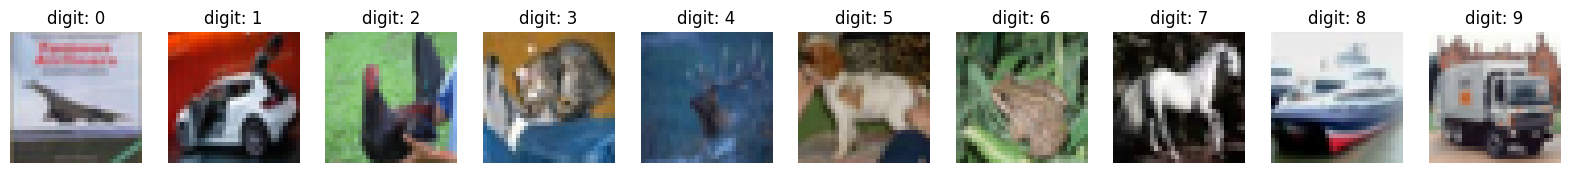

In [19]:
def visualize(with_predictions=False):
    plt.figure(figsize=(20, 10))
    predictions = model(demo_inputs).argmax(dim=1) if with_predictions else None
    for digit, index in demos.items():
        plt.subplot(1, 10, digit + 1)
        plt.imshow(demo_images[digit])
        if predictions is None:
            plt.title(f"digit: {digit}")
        else:
            plt.title(f"digit: {digit}\npred: {int(predictions[digit])}")
        plt.axis('off')
    plt.show()

visualize()

# Pretrain with CIFAR10 Dataset with Custom Model Code

In [20]:
def train_cnn_manual(model, train_loader, test_loader,
                     optimizer_type="momentum",
                     scheduler_type=None,
                     epochs=5,
                     initial_lr=0.001,
                     device="cpu"):

    # Store history for plotting later
    train_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    lr_hist = []

    # --------------------------------------------------
    # Initialize optimizer (manual implementation)
    # --------------------------------------------------
    if optimizer_type == "momentum":
        optimizer = SGDMomentum(model.params(), lr=initial_lr, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = AdamManual(model.params(), lr=initial_lr)
    else:
        raise ValueError("optimizer_type must be 'momentum' or 'adam'")

    # --------------------------------------------------
    # Training loop over epochs
    # --------------------------------------------------
    for epoch in range(1, epochs + 1):

        running_loss = 0.0   # sum of batch losses
        correct = 0          # number of correct predictions
        total = 0            # total samples

        # --------------------------------------------------
        # Learning rate scheduler (manual)
        # --------------------------------------------------
        if scheduler_type == "cosine":
            current_lr = cosine_lr(initial_lr, epoch - 1, epochs)
        elif scheduler_type == "step":
            current_lr = step_decay_lr(initial_lr, epoch - 1, drop=0.5, every=10)
        else:
            current_lr = initial_lr  # constant LR

        optimizer.lr = current_lr
        lr_hist.append(current_lr)

        # --------------------------------------------------
        # If model has dropout, enable training mode
        # --------------------------------------------------
        if hasattr(model, "dropout"):
            model.dropout.training = True

        # --------------------------------------------------
        # Loop over mini-batches
        # --------------------------------------------------
        for xb, yb in train_loader:

            # Move data to CPU/GPU
            xb = xb.to(device)
            yb = yb.to(device)

            # -----------------------
            # Forward pass
            # -----------------------
            logits = model.forward(xb)

            # -----------------------
            # Compute loss + gradient
            # -----------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # -----------------------
            # Backward pass
            # -----------------------
            model.backward(dlogits)

            # -----------------------
            # Update parameters
            # -----------------------
            optimizer.step()

            # -----------------------
            # Logging metrics
            # -----------------------
            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)   # predicted class
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # --------------------------------------------------
        # Compute epoch-level metrics
        # --------------------------------------------------
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Evaluate on test dataset
        test_acc = evaluate_cnn(model, test_loader, device=device)

        # Save history
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        # --------------------------------------------------
        # Print progress
        # --------------------------------------------------
        print(
            f"Epoch {epoch}: "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc*100:.2f}% "
            f"test_acc={test_acc*100:.2f}%"
        )

    # Return all logs for analysis/plots
    return train_loss_hist, train_acc_hist, test_acc_hist, lr_hist


In [21]:
# --------------------------------------------------
# Evaluate Manual CNN
#
# No gradients needed during evaluation
# Returns accuracy as a fraction (example: 0.1032)
# --------------------------------------------------

@torch.no_grad()
def evaluate_cnn(model, loader, device="cpu"):
    correct = 0
    total = 0

    # Turn off dropout during evaluation if it exists
    if hasattr(model, "dropout"):
        model.dropout.training = False

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model.forward(xb)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

    # Accuracy as fraction, not percent
    acc = correct / total

    # Turn dropout back on for training
    if hasattr(model, "dropout"):
        model.dropout.training = True

    return acc


In [23]:
cnn_momentum_opt_adam_maxpool = ManualCNN_opt_maxpool(num_classes=10, device=device)

loss_momentum_opt_adam_maxpool, train_acc_momentum_opt_adam_maxpool, test_acc_momentum_opt_adam_maxpool, lr_momentum_opt_adam_maxpool = train_cnn_manual(
    cnn_momentum_opt_adam_maxpool,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=5,
    initial_lr=0.001,
    device=device
)

# Save the initial state of the custom CNN model after training
# We store the .data of the parameters because params() returns (param, grad) where param is a tensor
initial_cnn_model_params = [(p.data.clone(), dp.data.clone()) for p, dp in cnn_momentum_opt_adam_maxpool.params()]

Epoch 1: lr=0.001000 train_loss=1.5390 train_acc=46.18% test_acc=56.56%
Epoch 2: lr=0.001000 train_loss=1.0715 train_acc=62.33% test_acc=65.16%
Epoch 3: lr=0.001000 train_loss=0.8866 train_acc=69.30% test_acc=67.49%
Epoch 4: lr=0.001000 train_loss=0.7618 train_acc=73.62% test_acc=69.33%
Epoch 5: lr=0.001000 train_loss=0.6646 train_acc=76.98% test_acc=71.40%


Custom Recovery Function for Custom CNN Model

In [24]:
print(f"=> setting up recovery for custom CNN model")

# Define a custom recovery function for ManualCNN_opt_maxpool
def recover_cnn_model_params(model_instance, saved_params):
    current_params = model_instance.params()
    for i, ((p_current, dp_current), (p_saved, dp_saved)) in enumerate(zip(current_params, saved_params)):
        p_current.data.copy_(p_saved.data)
        dp_current.data.copy_(dp_saved.data) # Also copy gradients, though they usually get zeroed by zero_grad()

# We will use this lambda to recover the original trained state for pruning experiments
recover_custom_model = lambda: recover_cnn_model_params(cnn_momentum_opt_adam_maxpool, initial_cnn_model_params)

# The best_checkpoint was for the Net model, not ManualCNN_opt_maxpool, so we remove its usage here.
# This cell now solely focuses on setting up recovery for the custom model.

=> setting up recovery for custom CNN model


# Let's First Evaluate the Accuracy and Model Size of Dense Model

Evaluate actual model accuracy and computation/memory metrics on custom CNN model

In [29]:
actual_model_accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device)
actual_model_size = get_model_size(cnn_momentum_opt_adam_maxpool)
num_parameters_actual_model = get_num_parameters(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)

# To calculate FLOPs, we need a sample input for the model. The Sample input shape is used to calculate shape.
# Assuming CIFAR10 images are 3x32x32.
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
flops_actual_model = get_model_macs(cnn_momentum_opt_adam_maxpool, sample_input, count_nonzero_only=True)

print(f"Actual dense model has {num_parameters_actual_model} nonzero parameters.")
print(f"Actual dense model without pruning has accuracy={actual_model_accuracy*100:.2f}%")
print(f"Actual dense model without pruning has size={actual_model_size/MiB:.2f} MiB")
print(f"Actual dense model has {flops_actual_model / 1e6:.2f} M FLOPs (MACs).")

Actual dense model has 423754 nonzero parameters.
Actual dense model without pruning has accuracy=71.40%
Actual dense model without pruning has size=1.62 MiB
Actual dense model has 14.83 M FLOPs (MACs).


# Let's Prune the Model and Re-Evaluate the Accuracy.

Pruning on custom model code with 3 layers and max pooling

In [30]:
sparsity = 0.70
# Call the custom recovery function for the ManualCNN_opt_maxpool model
recover_custom_model()
pruner = FineGrainedPruner(cnn_momentum_opt_adam_maxpool, sparsity)
pruner.apply(cnn_momentum_opt_adam_maxpool)
sparse_model_accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device) # Use evaluate_cnn
sparse_model_size = get_model_size(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy*100:.2f}%") # Adjust for percentage
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {actual_model_size/sparse_model_size:.2f}X smaller than " # Use actual_model_size
      f"the {actual_model_size/MiB:.2f} MiB dense model")
#visualize(True)

70.0% sparse model has accuracy=22.54%
70.0% sparse model has size=0.49 MiB, which is 3.32X smaller than the 1.62 MiB dense model


# Let's Fine-tune the Pruned Model to Get Higher Accuracy

Actual Custom Code fine tuning

In [31]:
num_finetune_epochs = 5

# Use AdamManual which is compatible with the custom model's params() structure
optimizer_manual = AdamManual(cnn_momentum_opt_adam_maxpool.params(), lr=0.001)

# Manual Step Decay Learning Rate Scheduler
initial_lr_finetune = 0.001
scheduler_step_size = 10
scheduler_gamma = 0.5

best_sparse_checkpoint = dict()
best_sparse_accuracy = 0
print(f'Finetuning Fine-grained Pruned Sparse Model')

for epoch in range(num_finetune_epochs):
    # Update LR for this epoch
    current_lr = initial_lr_finetune * (scheduler_gamma ** (epoch // scheduler_step_size))
    optimizer_manual.lr = current_lr # Update LR in the manual optimizer

    running_loss = 0.0
    # No need for correct and total for this part, as evaluate_cnn handles accuracy

    # Training phase
    for inputs, targets in tqdm(dataloader_CIFAR['train'], desc=f'Epoch {epoch+1} Train', leave=False):
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Zero gradients
        cnn_momentum_opt_adam_maxpool.zero_grad()

        # Forward pass
        logits = cnn_momentum_opt_adam_maxpool.forward(inputs)

        # Compute loss and dlogits (for manual backward)
        loss, dlogits = cross_entropy_loss_from_logits(logits, targets)

        # Backward pass
        cnn_momentum_opt_adam_maxpool.backward(dlogits)

        # Update parameters using manual Adam
        optimizer_manual.step()

        # Apply pruning mask after the optimizer step to enforce sparsity
        pruner.apply(cnn_momentum_opt_adam_maxpool)

        # Logging training loss
        running_loss += loss.item()

    # Evaluation phase using evaluate_cnn
    accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device) * 100 # evaluate_cnn returns fraction

    is_best = accuracy > best_sparse_accuracy
    if is_best:
        # For custom models, save parameters manually by cloning their data
        best_sparse_checkpoint['state_dict'] = [(p.data.clone(), dp.data.clone()) for p, dp in cnn_momentum_opt_adam_maxpool.params()]
        best_sparse_accuracy = accuracy

    print(f'    Epoch {epoch+1} Sparse Accuracy {accuracy:.2f}% / Best Sparse Accuracy: {best_sparse_accuracy:.2f}%')

# After the loop, load the best state if one was saved
if 'state_dict' in best_sparse_checkpoint:
    recover_cnn_model_params(cnn_momentum_opt_adam_maxpool, best_sparse_checkpoint['state_dict'])
else:
    print("No best checkpoint saved, potentially due to low initial accuracy.")

# Re-evaluate the best sparse model to print final results consistently
sparse_model_accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device) * 100
sparse_model_size = get_model_size(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {actual_model_size/sparse_model_size:.2f}X smaller than "
      f"the {actual_model_size/MiB:.2f} MiB dense model")

Finetuning Fine-grained Pruned Sparse Model


Epoch 1 Train:   0%|          | 0/196 [00:00<?, ?it/s]

    Epoch 1 Sparse Accuracy 70.52% / Best Sparse Accuracy: 70.52%


Epoch 2 Train:   0%|          | 0/196 [00:00<?, ?it/s]

    Epoch 2 Sparse Accuracy 71.77% / Best Sparse Accuracy: 71.77%


...

    Epoch 3 Sparse Accuracy 72.10% / Best Sparse Accuracy: 72.10%


Epoch 4 Train:   0%|          | 0/196 [00:00<?, ?it/s]

    Epoch 4 Sparse Accuracy 72.89% / Best Sparse Accuracy: 72.89%


Epoch 5 Train:   0%|          | 0/196 [00:00<?, ?it/s]

    Epoch 5 Sparse Accuracy 72.54% / Best Sparse Accuracy: 72.89%
70.0% sparse model has accuracy=72.89%
70.0% sparse model has size=0.49 MiB, which is 3.32X smaller than the 1.62 MiB dense model


Custom model recovery after fine tuning

In [32]:
recover_cnn_model_params(cnn_momentum_opt_adam_maxpool, best_sparse_checkpoint['state_dict'])
sparse_model_accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device) * 100 # Use evaluate_cnn and adjust for percentage
sparse_model_size = get_model_size(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {actual_model_size/sparse_model_size:.2f}X smaller than "
      f"the {actual_model_size/MiB:.2f} MiB dense model")

70.0% sparse model has accuracy=72.89%
70.0% sparse model has size=0.49 MiB, which is 3.32X smaller than the 1.62 MiB dense model


Get model evaluation metrics after fine tuning

In [34]:
recover_cnn_model_params(cnn_momentum_opt_adam_maxpool, best_sparse_checkpoint['state_dict'])
sparse_model_accuracy = evaluate_cnn(cnn_momentum_opt_adam_maxpool, dataloader_CIFAR['test'], device=device) * 100 # Use evaluate_cnn and adjust for percentage
sparse_model_size = get_model_size(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)

num_parameters_sparse = get_num_parameters(cnn_momentum_opt_adam_maxpool, count_nonzero_only=True)

# To calculate FLOPs, we need a sample input for the model. The Sample input shape is used to calculate shape.
# Assuming CIFAR10 images are 3x32x32.
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
flops_sparse = get_model_macs(cnn_momentum_opt_adam_maxpool, sample_input, count_nonzero_only=True)

print(f"Actual sparse model has {num_parameters_sparse} nonzero parameters.")
print(f"{sparsity*100}% sparse model with sparsity of 70% has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model with sparsity of 70%  has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {actual_model_size/sparse_model_size:.2f}X smaller than "
      f"the {actual_model_size/MiB:.2f} MiB dense model")
print(f"Actual sparse model has {flops_sparse / 1e6:.2f} M FLOPs (MACs).")


Actual sparse model has 127469 nonzero parameters.
70.0% sparse model with sparsity of 70% has accuracy=72.89%
70.0% sparse model with sparsity of 70%  has size=0.49 MiB, which is 3.32X smaller than the 1.62 MiB dense model
Actual sparse model has 4.45 M FLOPs (MACs).


# Ablation Study

Compressed Model Evaluation Metrics

In [35]:
print(f"Compressed model (70% sparse) has {num_parameters_sparse} nonzero parameters.")
print(f"Compressed model (70% sparse) has {flops_sparse / 1e6:.2f} M FLOPs (MACs).")
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {actual_model_size/sparse_model_size:.2f}X smaller than "
      f"the {actual_model_size/MiB:.2f} MiB dense model")



Compressed model (70% sparse) has 127469 nonzero parameters.
Compressed model (70% sparse) has 4.45 M FLOPs (MACs).
70.0% sparse model has accuracy=72.89%
70.0% sparse model has size=0.49 MiB, which is 3.32X smaller than the 1.62 MiB dense model


Baseline Dense Custom Model Evaluation Metrics

In [36]:
print(f"Actual dense model has {num_parameters_actual_model} nonzero parameters.")
print(f"Actual dense model without pruning has accuracy={actual_model_accuracy*100:.2f}%")
print(f"Actual dense model without pruning has size={actual_model_size/MiB:.2f} MiB")
print(f"Actual dense model has {flops_actual_model / 1e6:.2f} M FLOPs (MACs).")

Actual dense model has 423754 nonzero parameters.
Actual dense model without pruning has accuracy=71.40%
Actual dense model without pruning has size=1.62 MiB
Actual dense model has 14.83 M FLOPs (MACs).


Visualizations on Model evaluation metrics between Dense and Sparse Models

**Flops comparison for Dense and Sparse models**

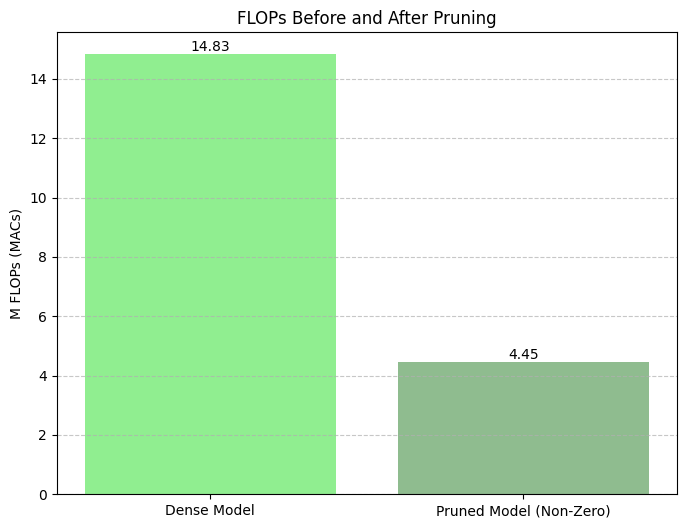

In [37]:
labels_flops = ['Dense Model', 'Pruned Model (Non-Zero)']
flops_counts = [flops_actual_model, flops_sparse] # 'flops' is already calculated for sparse

plt.figure(figsize=(8, 6))
plt.bar(labels_flops, [f / 1e6 for f in flops_counts], color=['lightgreen', 'darkseagreen'])
plt.ylabel('M FLOPs (MACs)')
plt.title('FLOPs Before and After Pruning')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for i, count in enumerate(flops_counts):
    plt.text(i, count / 1e6, f'{count / 1e6:.2f}', ha='center', va='bottom')

plt.show()

**Model Side Comparison between dense and sparse models**

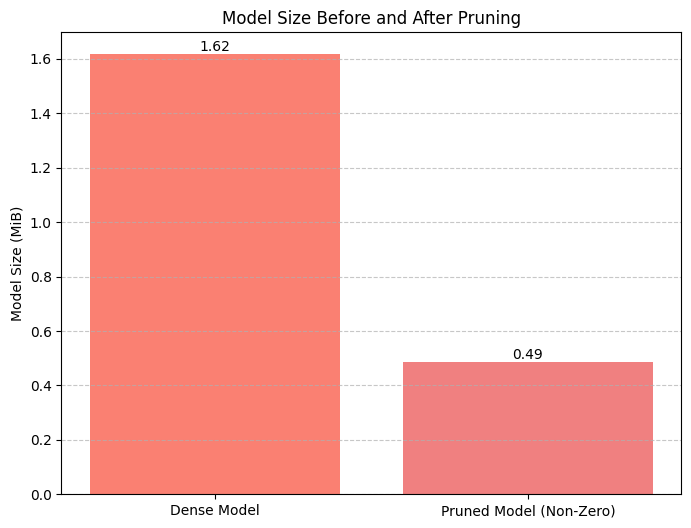

In [41]:
labels_size = ['Dense Model', 'Pruned Model (Non-Zero)']
# Ensure sparse_model_size is on CPU and converted to a Python number for plotting
size_counts = [actual_model_size / MiB, sparse_model_size.cpu().item() / MiB]

plt.figure(figsize=(8, 6))
plt.bar(labels_size, size_counts, color=['salmon', 'lightcoral'])
plt.ylabel('Model Size (MiB)')
plt.title('Model Size Before and After Pruning')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for i, count in enumerate(size_counts):
    plt.text(i, count, f'{count:.2f}', ha='center', va='bottom')

plt.show()

**# of remaining parameters before and after pruning**

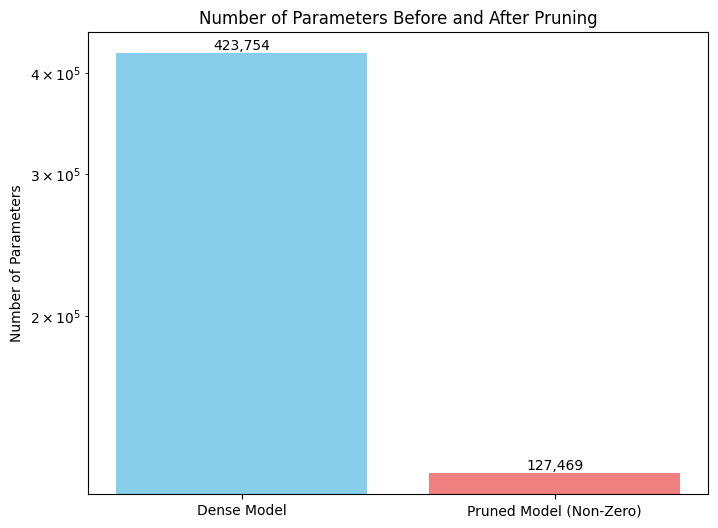

In [39]:
import matplotlib.pyplot as plt



# Non-zero parameters for the sparse model are already computed as 'num_parameters'

labels = ['Dense Model', 'Pruned Model (Non-Zero)']
# Ensure num_parameters is on CPU and converted to a Python number for plotting
parameter_counts = [num_parameters_actual_model.cpu().item(), num_parameters_sparse.cpu().item()]

plt.figure(figsize=(8, 6))
plt.bar(labels, parameter_counts, color=['skyblue', 'lightcoral'])
plt.ylabel('Number of Parameters')
plt.title('Number of Parameters Before and After Pruning')
plt.yscale('log') # Use a log scale due to potentially large difference
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for i, count in enumerate(parameter_counts):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom')

plt.show()

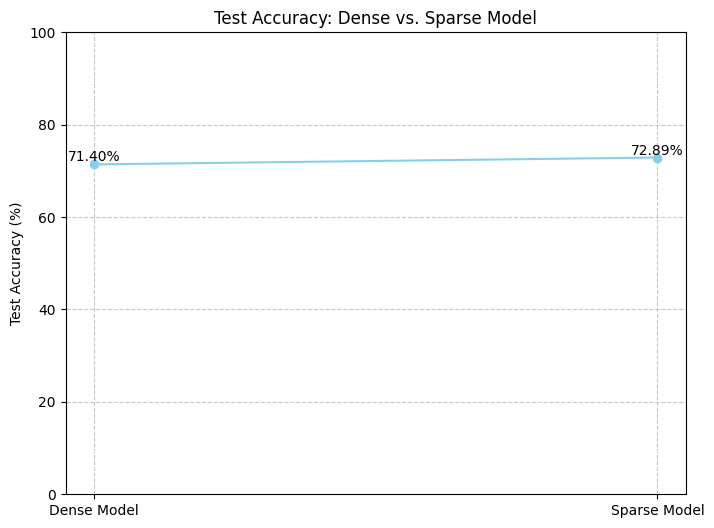

In [40]:
import matplotlib.pyplot as plt

# Prepare data for plotting
model_types = ['Dense Model', 'Sparse Model']
accuracies = [actual_model_accuracy * 100, sparse_model_accuracy]

plt.figure(figsize=(8, 6))
plt.plot(model_types, accuracies, marker='o', linestyle='-', color='skyblue')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy: Dense vs. Sparse Model')
plt.ylim(0, 100) # Accuracy range from 0 to 100
plt.grid(True, linestyle='--', alpha=0.7)

# Add numerical labels on top of points
for i, acc in enumerate(accuracies):
    plt.text(i, acc, f'{acc:.2f}%', ha='center', va='bottom')

plt.show()

Aspect 1: Compare model size, accuracy, # of parameters, flops across different sparsities (0.99, 0.95, 0.8)

Aspect 2: Compare model size, accuracy, # of parameters using different optimizer methods between Dense and Sparse models : (Adam/Step Learning Decay: Dense,   Momentum/Cosine LD: Sparse)

Aspect 3: Assess accuracy on iterative pruning method on sparse method in comparison to dense methods